In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv(r"/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/ml/qrf/predictions.csv")

In [3]:
df

,angle,sec_lower,sec_median,sec_upper,main_lower,main_median,main_upper
0,0.00,22.164630,22.251509,22.391684,21.214321,21.739553,22.247797
1,1.00,22.156840,22.244640,22.388948,21.151217,21.704990,22.200687
2,2.00,22.147675,22.239810,22.382826,21.096115,21.687284,22.140308
3,3.00,22.137758,22.233826,22.374573,21.048212,21.689924,22.060421
4,4.00,22.128801,22.228190,22.366726,21.010134,21.690123,21.972675
5,5.00,22.121223,22.223639,22.361410,20.980993,21.671806,21.881317
6,6.00,22.115345,22.217081,22.357456,20.963600,21.630688,21.815544
7,7.00,22.109556,22.212023,22.353794,20.953820,21.591188,21.777080
8,8.00,22.105894,22.209888,22.348518,20.951628,21.571028,21.734316
9,9.00,22.101524,22.209076,22.346214,20.956127,21.569845,21.698082


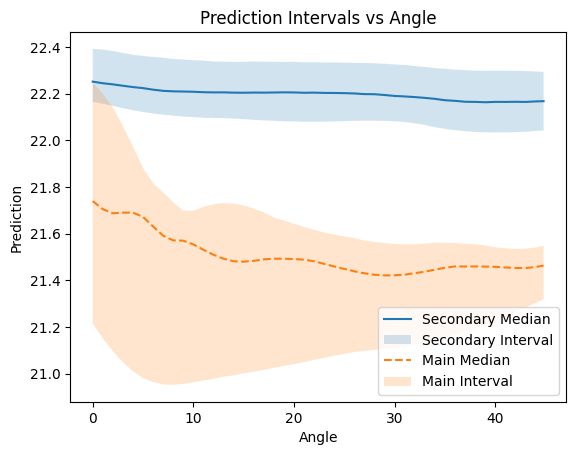

In [5]:
import matplotlib.pyplot as plt

plt.figure()

# Secondary
plt.plot(df["angle"], df["sec_median"], label="Secondary Median")
plt.fill_between(
    df["angle"],
    df["sec_lower"],
    df["sec_upper"],
    alpha=0.2,
    label="Secondary Interval"
)

# Main
plt.plot(df["angle"], df["main_median"], linestyle="--", label="Main Median")
plt.fill_between(
    df["angle"],
    df["main_lower"],
    df["main_upper"],
    alpha=0.2,
    label="Main Interval"
)

plt.xlabel("Angle")
plt.ylabel("Prediction")
plt.legend()
plt.title("Prediction Intervals vs Angle")

plt.show()

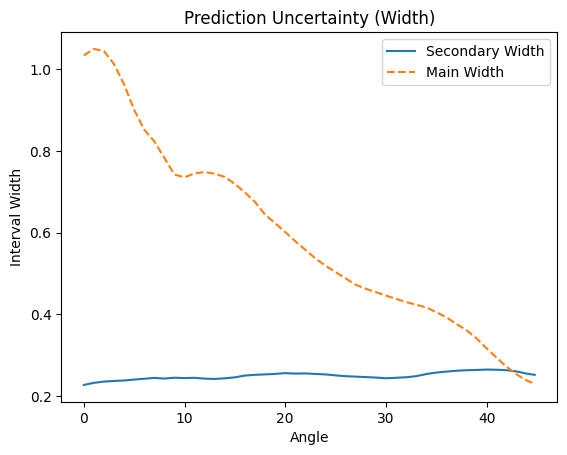

In [6]:
df["sec_width"] = df["sec_upper"] - df["sec_lower"]
df["main_width"] = df["main_upper"] - df["main_lower"]

plt.figure()

plt.plot(df["angle"], df["sec_width"], label="Secondary Width")
plt.plot(df["angle"], df["main_width"], linestyle="--", label="Main Width")

plt.xlabel("Angle")
plt.ylabel("Interval Width")
plt.title("Prediction Uncertainty (Width)")
plt.legend()

plt.show()

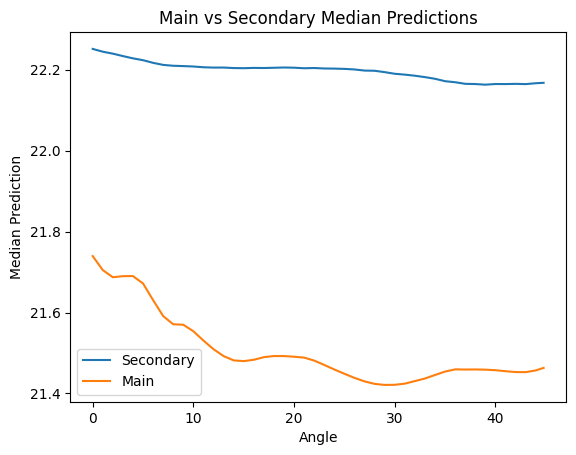

In [7]:
plt.figure()

plt.plot(df["angle"], df["sec_median"], label="Secondary")
plt.plot(df["angle"], df["main_median"], label="Main")

plt.xlabel("Angle")
plt.ylabel("Median Prediction")
plt.title("Main vs Secondary Median Predictions")
plt.legend()

plt.show()

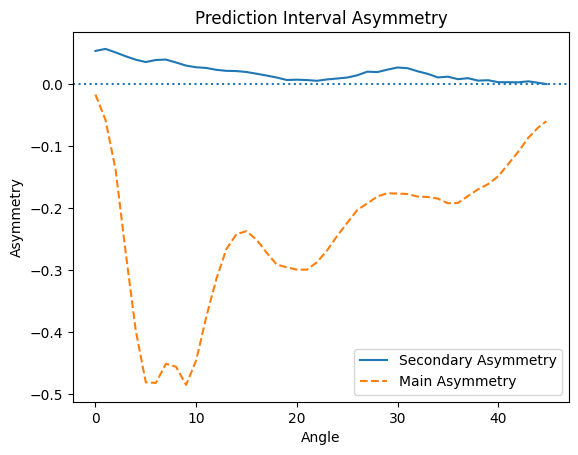

In [8]:
df["sec_asym"] = (
    (df["sec_upper"] - df["sec_median"]) -
    (df["sec_median"] - df["sec_lower"])
)

df["main_asym"] = (
    (df["main_upper"] - df["main_median"]) -
    (df["main_median"] - df["main_lower"])
)

plt.figure()

plt.plot(df["angle"], df["sec_asym"], label="Secondary Asymmetry")
plt.plot(df["angle"], df["main_asym"], linestyle="--", label="Main Asymmetry")

plt.axhline(0, linestyle=":")
plt.xlabel("Angle")
plt.ylabel("Asymmetry")
plt.title("Prediction Interval Asymmetry")
plt.legend()

plt.show()

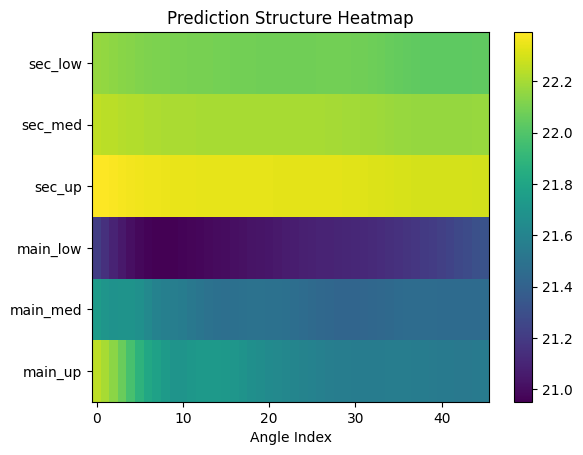

In [9]:
import numpy as np

heat_data = np.vstack([
    df["sec_lower"],
    df["sec_median"],
    df["sec_upper"],
    df["main_lower"],
    df["main_median"],
    df["main_upper"],
])

plt.figure()
plt.imshow(heat_data, aspect='auto')

plt.yticks(
    range(6),
    ["sec_low", "sec_med", "sec_up", "main_low", "main_med", "main_up"]
)

plt.colorbar()
plt.xlabel("Angle Index")
plt.title("Prediction Structure Heatmap")

plt.show()